# 01 — Parameters and ModulatableParameter

This notebook covers `caspy.Parameter` and `caspy.ModulatableParameter` — the foundation of every modulatable value in caspy.

**What we cover:**
1. Constructing parameters, setting ranges and scales
2. The one-pole smoother — `process()` vs `skip()`
3. Linear vs logarithmic scaling
4. Modulation accumulation on `ModulatableParameter`
5. Visualising smoother convergence
6. Interactive widget to explore smoothing time

In [1]:
import caspy
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

SR = 44100
print('caspy loaded')

caspy loaded


## 1. Basic Parameter construction

In [2]:
# Frequency parameter: 20–20000 Hz, log scale, default at normalised 0.5
freq = caspy.Parameter(20.0, 20000.0, 0.5)
freq.set_range(20.0, 20000.0, caspy.ParameterScale.Logarithmic)

# Skip to steady state before reading
freq.skip(1000)

print(f'value():            {freq.value():.2f} Hz')
print(f'value_normalised(): {freq.value_normalised():.4f}')
print(f'geometric midpoint: {(20 * 20000) ** 0.5:.2f} Hz  (expected for norm=0.5 on log scale)')

value():            632.46 Hz
value_normalised(): 0.5000
geometric midpoint: 632.46 Hz  (expected for norm=0.5 on log scale)


In [3]:
# Linear parameter: gain 0–1
gain = caspy.Parameter(0.0, 1.0, 0.0)
gain.skip(1000)
gain.set_base_normalised(0.75)
gain.skip(1000)
print(f'gain: {gain.value():.3f}  (expected 0.75)')

gain: 0.750  (expected 0.75)


## 2. Smoother convergence

The one-pole smoother asymptotically approaches the target. `set_smoothing_time(t, sr)` sets the time for ~99% convergence.

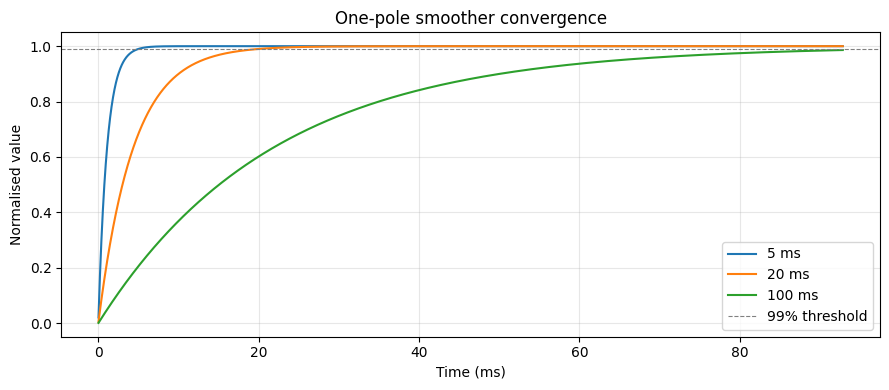

In [4]:
def capture_smoothing(start_norm, end_norm, smooth_ms, n_samples=4096, sr=SR):
    """Render the smoother trajectory from start → end normalised value."""
    p = caspy.Parameter(0.0, 1.0, start_norm)
    p.set_smoothing_time(smooth_ms / 1000.0, float(sr))
    p.skip(2000)  # settle at start
    p.set_base_normalised(end_norm)
    out = np.empty(n_samples, dtype=np.float32)
    for i in range(n_samples):
        p.process()
        out[i] = p.value_normalised()
    return out

t_ms_values = [5, 20, 100]
n = 4096
t_axis = np.arange(n) / SR * 1000  # ms

fig, ax = plt.subplots(figsize=(9, 4))
for t_ms in t_ms_values:
    traj = capture_smoothing(0.0, 1.0, t_ms, n)
    ax.plot(t_axis, traj, label=f'{t_ms} ms')

ax.axhline(0.99, color='grey', linestyle='--', linewidth=0.8, label='99% threshold')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Normalised value')
ax.set_title('One-pole smoother convergence')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Log vs Linear scaling

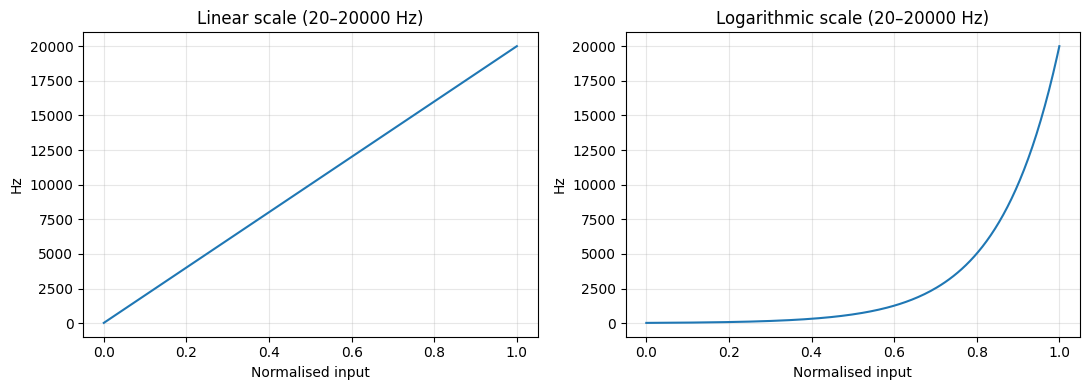

Log midpoint at norm=0.5: 643.5 Hz  (geometric mean = 632.5 Hz)


In [5]:
norms = np.linspace(0, 1, 200)

def scan_scale(scale, lo, hi):
    p = caspy.Parameter(lo, hi, 0.0)
    p.set_range(lo, hi, scale)
    vals = []
    for n in norms:
        p.set_base_normalised(float(n))
        p.skip(2000)
        vals.append(p.value())
    return np.array(vals)

lin_vals = scan_scale(caspy.ParameterScale.Linear,      20, 20000)
log_vals = scan_scale(caspy.ParameterScale.Logarithmic, 20, 20000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, title in zip(axes, [lin_vals, log_vals], ['Linear', 'Logarithmic']):
    ax.plot(norms, vals)
    ax.set_xlabel('Normalised input')
    ax.set_ylabel('Hz')
    ax.set_title(f'{title} scale (20–20000 Hz)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Log midpoint at norm=0.5: {log_vals[100]:.1f} Hz  (geometric mean = {(20*20000)**0.5:.1f} Hz)')

## 4. ModulatableParameter — modulation accumulation

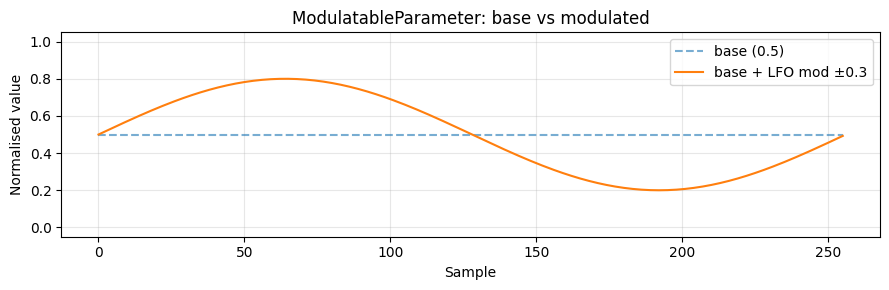

Modulated range: [0.200, 0.800]  (clamped to [0,1])


In [6]:
# Simulate one audio block: base at 0.5, LFO sweeps ±0.3
p = caspy.ModulatableParameter(0.0, 1.0, 0.5)
p.skip(2000)

block = 256
lfo_mod = 0.3 * np.sin(2 * np.pi * np.arange(block) / block)  # one cycle of modulation

out_base = np.empty(block)
out_mod  = np.empty(block)

for i in range(block):
    p.process()
    out_base[i] = p.value_normalised()          # without modulation

p.skip(2000)  # re-settle

for i in range(block):
    p.clear_modulation()
    p.add_modulation(float(lfo_mod[i]))
    p.process()
    out_mod[i] = p.value_normalised()           # with modulation

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(out_base, label='base (0.5)', linestyle='--', alpha=0.6)
ax.plot(out_mod,  label='base + LFO mod ±0.3')
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Sample')
ax.set_ylabel('Normalised value')
ax.set_title('ModulatableParameter: base vs modulated')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Modulated range: [{out_mod.min():.3f}, {out_mod.max():.3f}]  (clamped to [0,1])')

## 5. Interactive: explore smoothing time

In [7]:
out_widget = widgets.Output()

slider_ms    = widgets.FloatSlider(value=20, min=1, max=500, step=1,
                                    description='Smooth (ms)', continuous_update=True)
slider_start = widgets.FloatSlider(value=0.0, min=0, max=1, step=0.05,
                                    description='Start norm')
slider_end   = widgets.FloatSlider(value=1.0, min=0, max=1, step=0.05,
                                    description='End norm')

def update(_):
    traj = capture_smoothing(slider_start.value, slider_end.value, slider_ms.value, n_samples=8192)
    t_ax = np.arange(len(traj)) / SR * 1000
    target = slider_end.value
    # find 99% convergence sample
    diff = np.abs(traj - target)
    threshold = abs(slider_end.value - slider_start.value) * 0.01
    conv_idx  = np.argmax(diff < threshold) if np.any(diff < threshold) else len(traj) - 1

    with out_widget:
        out_widget.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.plot(t_ax, traj, color='steelblue')
        ax.axhline(target, color='orange', linestyle='--', linewidth=0.8, label='target')
        ax.axvline(t_ax[conv_idx], color='green', linestyle=':', linewidth=0.9,
                   label=f'99% at {t_ax[conv_idx]:.1f} ms')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Normalised value')
        ax.set_title('Parameter smoother')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

for w in [slider_ms, slider_start, slider_end]:
    w.observe(update, names='value')

update(None)
display(widgets.VBox([slider_start, slider_end, slider_ms, out_widget]))